In [2]:
import os
import pandas as pd

[Dataset](https://gitlab.com/techsupportHF/HF_Lung_V1)

In [3]:
base = "HF_lung_v1"
test = base + "\\test\\"
train = base + "\\train\\"

In [4]:
os.listdir(test)

['steth_20190801_09_46_05.wav',
 'steth_20190801_09_46_05_label.txt',
 'steth_20190801_09_46_26.wav',
 'steth_20190801_09_46_26_label.txt',
 'steth_20190801_09_46_51.wav',
 'steth_20190801_09_46_51_label.txt',
 'steth_20190801_09_47_36.wav',
 'steth_20190801_09_47_36_label.txt',
 'steth_20190801_09_47_58.wav',
 'steth_20190801_09_47_58_label.txt',
 'steth_20190801_09_48_31.wav',
 'steth_20190801_09_48_31_label.txt',
 'steth_20190801_09_49_03.wav',
 'steth_20190801_09_49_03_label.txt',
 'steth_20190801_09_51_07.wav',
 'steth_20190801_09_51_07_label.txt',
 'steth_20190801_09_52_21.wav',
 'steth_20190801_09_52_21_label.txt',
 'steth_20190801_09_52_41.wav',
 'steth_20190801_09_52_41_label.txt',
 'steth_20190801_09_53_09.wav',
 'steth_20190801_09_53_09_label.txt',
 'steth_20190801_09_53_45.wav',
 'steth_20190801_09_53_45_label.txt',
 'steth_20190801_09_54_19.wav',
 'steth_20190801_09_54_19_label.txt',
 'steth_20190801_09_54_44.wav',
 'steth_20190801_09_54_44_label.txt',
 'steth_20190801_09_

In [6]:
with open(test + '\\steth_20190801_09_53_45_label.txt', 'r') as f:
    print(f.read())

I 00:00:01.647 00:00:02.752
Stridor 00:00:02.089 00:00:02.752
I 00:00:04.161 00:00:05.004
I 00:00:06.272 00:00:07.015
E 00:00:07.015 00:00:07.539
I 00:00:08.563 00:00:09.128
E 00:00:09.166 00:00:09.731
I 00:00:10.353 00:00:11.299
E 00:00:11.299 00:00:11.961



# Data Preparation & Exploratory Data Analysis (EDA)


## 1. Create CSV from label files


In [7]:
import glob
from datetime import datetime

data = []
for split, path in [('train', train), ('test', test)]:
    txt_files = glob.glob(path + '*_label.txt')
    for txt_file in txt_files:
        wav_file = txt_file.replace('_label.txt', '.wav')
        wav_filename = os.path.basename(wav_file)
        
        with open(txt_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 3:
                    label = parts[0]
                    start = parts[1]
                    end = parts[2]
                    
                    # Convert to seconds
                    try:
                        pt_start = datetime.strptime(start, '%H:%M:%S.%f')
                        start_sec = pt_start.hour * 3600 + pt_start.minute * 60 + pt_start.second + pt_start.microsecond / 1e6
                        
                        pt_end = datetime.strptime(end, '%H:%M:%S.%f')
                        end_sec = pt_end.hour * 3600 + pt_end.minute * 60 + pt_end.second + pt_end.microsecond / 1e6
                        
                        duration = end_sec - start_sec
                    except ValueError:
                        start_sec = None
                        end_sec = None
                        duration = None
                        
                    data.append({
                        'filename': wav_filename,
                        'split': split,
                        'label': label,
                        'start_time': start_sec,
                        'end_time': end_sec,
                        'duration': duration
                    })

df = pd.DataFrame(data)
csv_path = os.path.join(base, 'HF_Lung_V1_annotations.csv')
df.to_csv(csv_path, index=False)
print(f'Saved CSV to {csv_path} with {len(df)} annotations.')
display(df.head())

Saved CSV to HF_lung_v1\HF_Lung_V1_annotations.csv with 81933 annotations.


,filename,split,label,start_time,end_time,duration
0,steth_20180814_09_37_11.wav,train,I,1.500,2.457,0.957
1,steth_20180814_09_37_11.wav,train,D,1.500,2.457,0.957
2,steth_20180814_09_37_11.wav,train,E,2.608,3.637,1.029
3,steth_20180814_09_37_11.wav,train,D,2.608,3.637,1.029
4,steth_20180814_09_37_11.wav,train,I,5.227,6.350,1.123


## 2. EDA: Basic Information


In [8]:
print('Dataframe Info:')
df.info()
print()
print('Dataframe Description:')
display(df.describe(include='all'))

Dataframe Info:
<class 'pandas.DataFrame'>
RangeIndex: 81933 entries, 0 to 81932
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   filename    81933 non-null  str    
 1   split       81933 non-null  str    
 2   label       81933 non-null  str    
 3   start_time  81933 non-null  float64
 4   end_time    81933 non-null  float64
 5   duration    81933 non-null  float64
dtypes: float64(3), str(3)
memory usage: 3.8 MB

Dataframe Description:


,filename,split,label,start_time,end_time,duration
count,81933,81933,81933,81933.000000,81933.000000,81933.000000
unique,9707,2,6,NaN,NaN,NaN
top,steth_20190722_16_35_33.wav,train,I,NaN,NaN,NaN
freq,44,68082,34095,NaN,NaN,NaN
mean,NaN,NaN,NaN,7.109657,8.019934,0.910277
std,NaN,NaN,NaN,4.215688,4.212141,0.414731
min,NaN,NaN,NaN,0.000000,0.101000,0.001000
25%,NaN,NaN,NaN,3.463000,4.387000,0.649000
50%,NaN,NaN,NaN,7.116000,8.029000,0.855000
75%,NaN,NaN,NaN,10.684000,11.632000,1.063000


In [9]:
print('Missing Values:')
display(df.isnull().sum())

Missing Values:


filename      0
split         0
label         0
start_time    0
end_time      0
duration      0
dtype: int64

In [10]:
total_files = df['filename'].nunique()
total_annotations = len(df)
unique_labels = df['label'].nunique()

print(f'Total number of unique audio files: {total_files}')
print(f'Total number of annotations: {total_annotations}')
print(f'Unique Label Types: {unique_labels}')
print(f'Labels: {df["label"].unique().tolist()}')

Total number of unique audio files: 9707
Total number of annotations: 81933
Unique Label Types: 6
Labels: ['I', 'D', 'E', 'Rhonchi', 'Wheeze', 'Stridor']


## 3. EDA: Visualizations


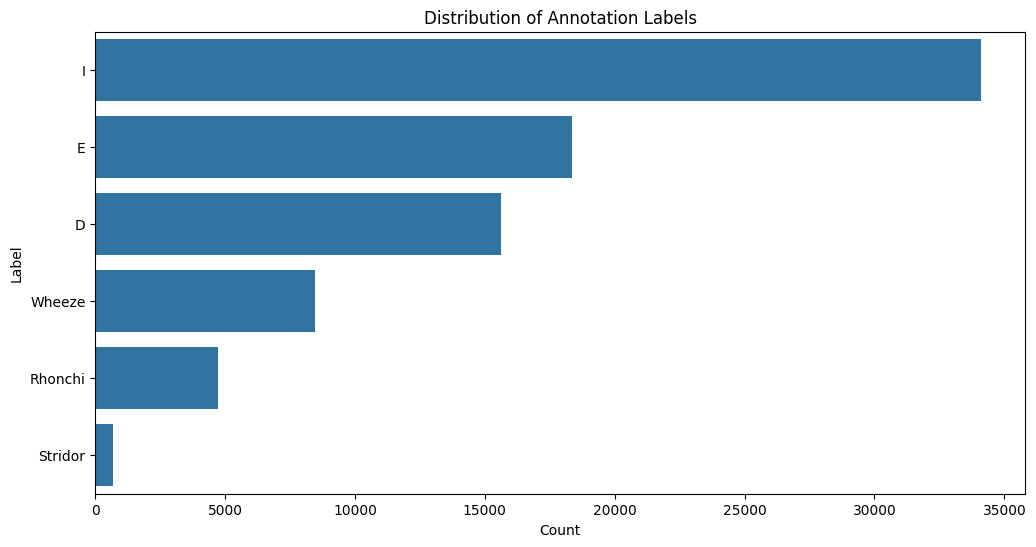

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index)
plt.title('Distribution of Annotation Labels')
plt.xlabel('Count')
plt.ylabel('Label')
plt.show()

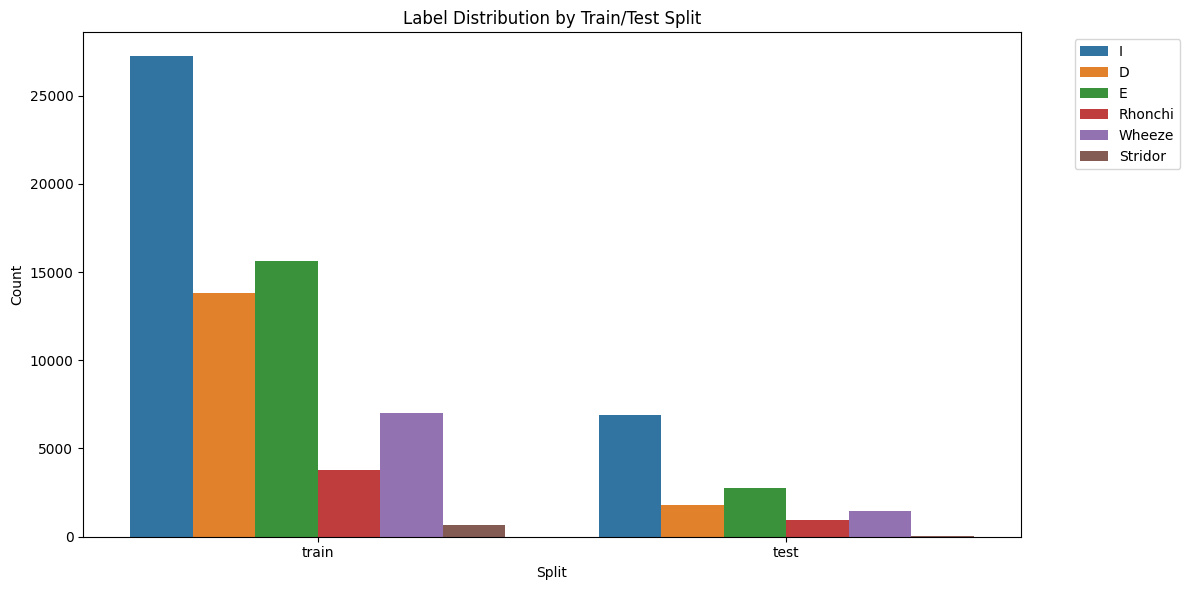

In [12]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='split', hue='label')
plt.title('Label Distribution by Train/Test Split')
plt.xlabel('Split')
plt.ylabel('Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

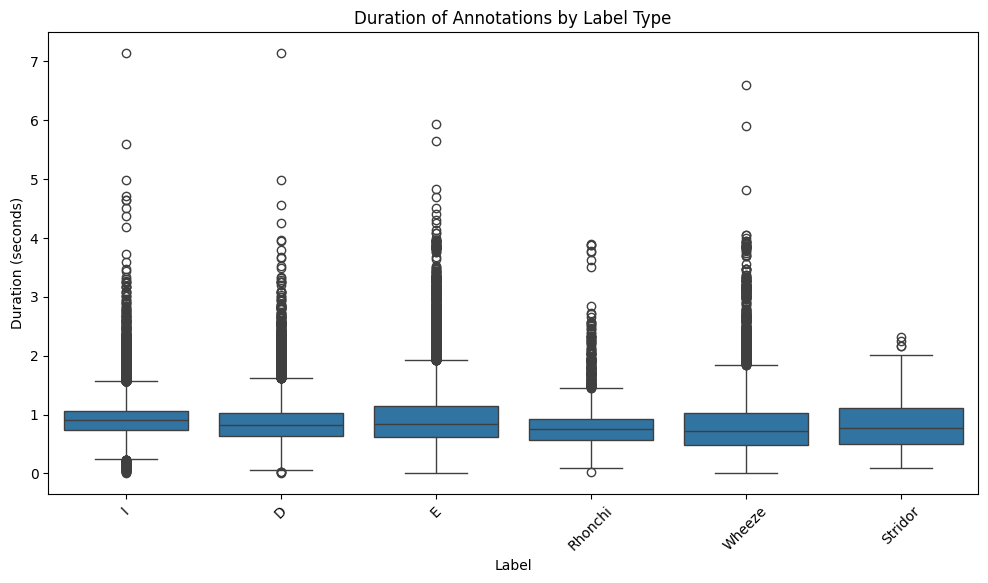

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='label', y='duration')
plt.title('Duration of Annotations by Label Type')
plt.xlabel('Label')
plt.ylabel('Duration (seconds)')
plt.xticks(rotation=45)
plt.show()

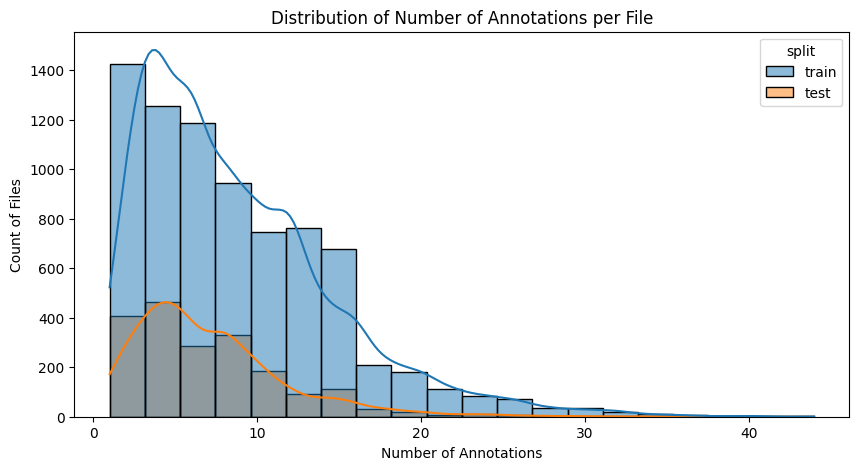

In [14]:
# File level statistics
file_stats = df.groupby('filename').agg(
    split=('split', 'first'),
    num_annotations=('label', 'count')
).reset_index()

plt.figure(figsize=(10, 5))
sns.histplot(data=file_stats, x='num_annotations', hue='split', bins=20, kde=True)
plt.title('Distribution of Number of Annotations per File')
plt.xlabel('Number of Annotations')
plt.ylabel('Count of Files')
plt.show()

## Visualize Sounds

In [17]:
import os
import glob
import random
from IPython.display import Audio, display

# Paths to the dataset directories
# Ensure 'train' and 'test' variables are defined as in your notebook:
# train = base + "\\train\\"
# test = base + "\\test\\"

def display_random_hf_samples(num_samples=3):
    print(f"--- Displaying {num_samples} Random Samples ---")
    
    # Gather all .wav files from both train and test directories
    all_wav_files = glob.glob(os.path.join(train, '*.wav')) + glob.glob(os.path.join(test, '*.wav'))
    
    if not all_wav_files:
        print("No .wav files found. Please check your directory paths.")
        return
    
    # Pick random files
    sampled_files = random.sample(all_wav_files, min(num_samples, len(all_wav_files)))
    
    for wav_path in sampled_files:
        filename = os.path.basename(wav_path)
        label_path = wav_path.replace('.wav', '_label.txt')
        
        print(f"\n🎧 File: {filename}")
        
        # Read and print the labels
        labels = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 3:
                        lbl = parts[0]
                        start = parts[1]
                        end = parts[2]
                        labels.append(f"{lbl} ({start} - {end})")
            
            if labels:
                print("Annotations:")
                for lbl in labels:
                    print(f"  - {lbl}")
            else:
                print("Annotations: None found in label file.")
        else:
            print("Annotations: No label file found.")
            
        # Display the interactive audio player
        display(Audio(wav_path))
        print("-" * 50)

# Run the function
display_random_hf_samples(3)

--- Displaying 3 Random Samples ---

🎧 File: trunc_2019-07-17-11-36-48-L6_3.wav
Annotations:
  - E (00:00:03.704 - 00:00:04.463)
  - D (00:00:03.704 - 00:00:04.463)
  - I (00:00:04.483 - 00:00:05.327)
  - E (00:00:05.376 - 00:00:06.002)
  - D (00:00:05.376 - 00:00:06.002)
  - I (00:00:06.011 - 00:00:06.992)
  - E (00:00:07.087 - 00:00:07.531)
  - D (00:00:07.087 - 00:00:07.531)
  - I (00:00:07.638 - 00:00:08.386)
  - E (00:00:08.493 - 00:00:08.967)
  - D (00:00:08.493 - 00:00:08.967)
  - I (00:00:09.215 - 00:00:10.059)
  - E (00:00:10.108 - 00:00:10.582)
  - D (00:00:10.108 - 00:00:10.582)
  - I (00:00:10.659 - 00:00:11.902)
  - E (00:00:12.161 - 00:00:12.768)
  - D (00:00:12.161 - 00:00:12.768)
  - I (00:00:12.788 - 00:00:13.821)
  - E (00:00:13.928 - 00:00:14.478)
  - D (00:00:13.928 - 00:00:14.478)
  - I (00:00:14.498 - 00:00:15.000)
  - D (00:00:14.498 - 00:00:15.000)


--------------------------------------------------

🎧 File: steth_20190102_08_40_49.wav
Annotations:
  - Wheeze (00:00:00.000 - 00:00:01.332)
  - I (00:00:04.071 - 00:00:05.041)
  - E (00:00:05.160 - 00:00:06.351)
  - Wheeze (00:00:05.160 - 00:00:06.351)
  - I (00:00:09.110 - 00:00:10.121)
  - Rhonchi (00:00:09.110 - 00:00:10.121)
  - E (00:00:10.239 - 00:00:11.411)
  - Rhonchi (00:00:10.239 - 00:00:11.411)


--------------------------------------------------

🎧 File: trunc_2019-05-16-14-23-13-L5_7.wav
Annotations:
  - D (00:00:02.594 - 00:00:03.612)
  - I (00:00:02.606 - 00:00:03.635)
  - E (00:00:03.630 - 00:00:04.554)
  - D (00:00:03.630 - 00:00:04.554)
  - I (00:00:05.855 - 00:00:06.885)
  - D (00:00:05.855 - 00:00:06.885)
  - E (00:00:06.903 - 00:00:07.402)
  - D (00:00:06.903 - 00:00:07.402)
  - I (00:00:09.517 - 00:00:10.452)
  - D (00:00:09.517 - 00:00:10.452)
  - E (00:00:10.458 - 00:00:11.287)
  - D (00:00:10.458 - 00:00:11.287)
  - I (00:00:13.378 - 00:00:14.407)
  - D (00:00:13.378 - 00:00:14.407)
  - E (00:00:14.414 - 00:00:15.000)
  - Wheeze (00:00:14.638 - 00:00:15.000)


--------------------------------------------------
